# 📘 Week 3 - Day 13
# Model Evaluation: Confusion Matrix, ROC-AUC, F1 Score & Cross Validation

This notebook follows the internship Day 13 objectives.

## Objectives

- Train Logistic Regression model
- Evaluate using Confusion Matrix
- Generate Classification Report
- Calculate Precision, Recall and F1 Score
- Plot ROC Curve
- Calculate ROC-AUC
- Perform 5-Fold Cross Validation
- Save trained model and scaler using Joblib


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize
import joblib


## Load Dataset

In [2]:
iris = load_iris(as_frame=True)

df = iris.frame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Dataset Information

In [3]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Feature & Target Separation

In [4]:
X = df.iloc[:,:-1]
y = df["target"]

X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Train Test Split

In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Feature Scaling

In [6]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


## Train Logistic Regression Model

In [7]:
model=LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

y_pred=model.predict(X_test)


## Accuracy

In [8]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.9333333333333333


## Confusion Matrix

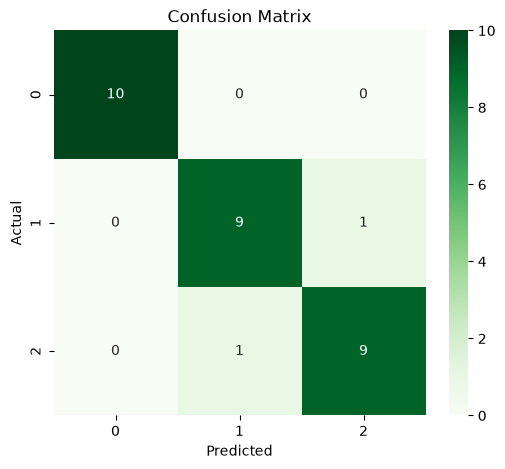

In [9]:
cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Classification Report

In [10]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Precision, Recall and F1 Score

In [11]:
precision=precision_score(y_test,y_pred,average="weighted")
recall=recall_score(y_test,y_pred,average="weighted")
f1=f1_score(y_test,y_pred,average="weighted")

print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)


Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1 Score: 0.9333333333333333


## ROC Curve & ROC-AUC

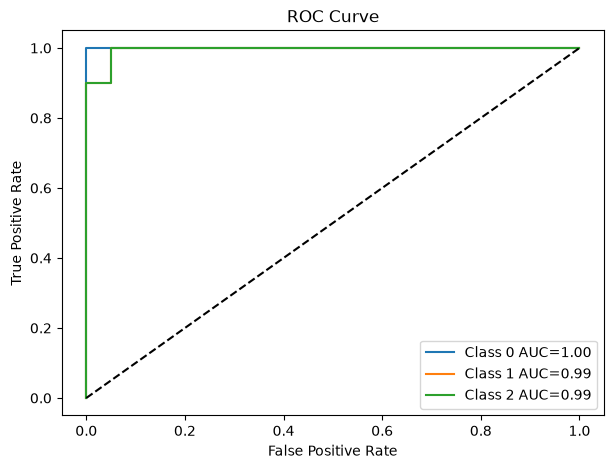

In [12]:
y_test_bin=label_binarize(y_test,classes=[0,1,2])

probs=model.predict_proba(X_test)

plt.figure(figsize=(7,5))

for i in range(3):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],probs[:,i])
    auc=roc_auc_score(y_test_bin[:,i],probs[:,i])
    plt.plot(fpr,tpr,label=f"Class {i} AUC={auc:.2f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Cross Validation

In [13]:
scores=cross_val_score(
    LogisticRegression(max_iter=1000),
    StandardScaler().fit_transform(X),
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Scores:",scores)
print("Mean:",scores.mean())
print("Std:",scores.std())


Scores: [0.96658312 1.         0.93265993 0.89974937 1.        ]
Mean: 0.9597984861142755
Std: 0.03904036826789795


## Save Model

In [14]:
joblib.dump(model,"logistic_model.pkl")
joblib.dump(scaler,"scaler.pkl")

print("Model Saved Successfully")


Model Saved Successfully


# Conclusion

In this notebook we learned:

- Model Evaluation
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1 Score
- ROC Curve
- ROC-AUC
- Cross Validation
- Saving ML Model
